In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("09-iris.csv")

In [3]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

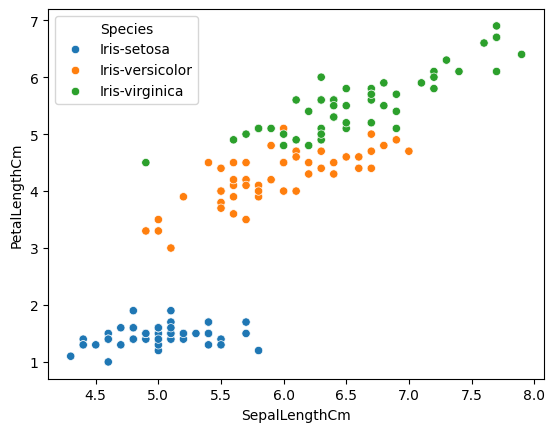

In [6]:
sns.scatterplot(x=df['SepalLengthCm'], y=df['PetalLengthCm'], hue=df['Species'])
plt.show()

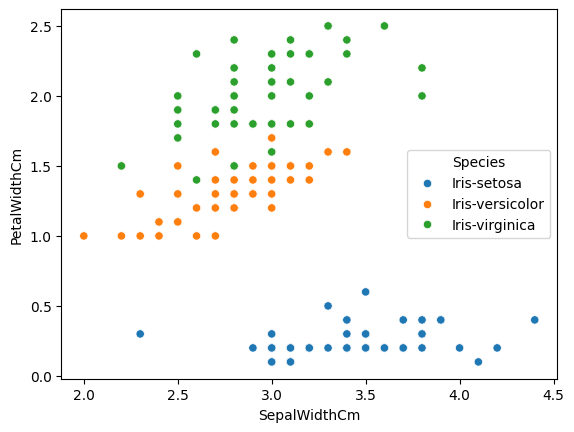

In [7]:
sns.scatterplot(x=df['SepalWidthCm'], y=df['PetalWidthCm'], hue=df['Species'])
plt.show()

In [8]:
df = df.drop("Id", axis=1)

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df['Species'].values

In [11]:
y

<StringArray>
[   'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',
 ...
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica']
Length: 150, dtype: str

In [12]:
# label encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()

In [15]:
y = le.fit_transform(y)

In [16]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([120, 4]),
 torch.Size([30, 4]),
 torch.Size([120]),
 torch.Size([30]))

In [22]:
# from torch import nn
# class IrisClassifier(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         self.layer_1 = nn.Linear(in_features=4, out_features=16)
#         self.layer_2 = nn.Linear(in_features=16, out_features=16)
#         self.layer_3 = nn.Linear(in_features=16, out_features=3)

#         self.relu = nn.ReLU()

#     def forward(self, x):
#         return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [23]:
from torch import nn
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [24]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [25]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [26]:
model(X_test)[:5]

tensor([[ 0.3716, -0.0264, -0.0125],
        [ 0.4197, -0.2575, -0.3908],
        [ 0.3843, -0.1920, -0.1884],
        [ 0.3928, -0.1889, -0.1833],
        [ 0.3648, -0.0211, -0.0168]], grad_fn=<SliceBackward0>)

In [27]:
model(X_test)[0].shape

torch.Size([3])

In [28]:
y_logits = model(X_test)

In [29]:
y_pred_probs = torch.softmax(y_logits, dim=1)

In [30]:
y_pred_probs[:5]

tensor([[0.4251, 0.2855, 0.2895],
        [0.5121, 0.2602, 0.2277],
        [0.4704, 0.2643, 0.2653],
        [0.4715, 0.2635, 0.2650],
        [0.4233, 0.2877, 0.2890]], grad_fn=<SliceBackward0>)

In [31]:
y_pred_probs[0]

tensor([0.4251, 0.2855, 0.2895], grad_fn=<SelectBackward0>)

In [32]:
torch.argmax(y_pred_probs[0])

tensor(0)

In [33]:
torch.softmax(y_logits, dim=1).argmax(dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

In [34]:
epochs = 200

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits,y_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = calculate_accuracy(y_test, test_pred)
    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch %20 == 0:
        print(f"Epoch:{epoch}, Loss:{loss}, Accuracy:{acc}, Test_Loss:{test_loss}, Test_Accuracy:{test_acc}")
    

Epoch:0, Loss:1.240099310874939, Accuracy:33.33333333333333, Test_Loss:1.1470526456832886, Test_Accuracy:33.33333333333333
Epoch:20, Loss:0.6974212527275085, Accuracy:67.5, Test_Loss:0.6564071774482727, Test_Accuracy:66.66666666666666
Epoch:40, Loss:0.30239853262901306, Accuracy:97.5, Test_Loss:0.2903212010860443, Test_Accuracy:100.0
Epoch:60, Loss:0.10712415724992752, Accuracy:97.5, Test_Loss:0.10892779380083084, Test_Accuracy:100.0
Epoch:80, Loss:0.06929195672273636, Accuracy:98.33333333333333, Test_Loss:0.0663180723786354, Test_Accuracy:100.0
Epoch:100, Loss:0.06036590412259102, Accuracy:97.5, Test_Loss:0.053960636258125305, Test_Accuracy:100.0
Epoch:120, Loss:0.056347206234931946, Accuracy:98.33333333333333, Test_Loss:0.047870222479104996, Test_Accuracy:100.0
Epoch:140, Loss:0.05372420325875282, Accuracy:98.33333333333333, Test_Loss:0.04514743387699127, Test_Accuracy:100.0
Epoch:160, Loss:0.05161488801240921, Accuracy:98.33333333333333, Test_Loss:0.04415228217840195, Test_Accuracy:

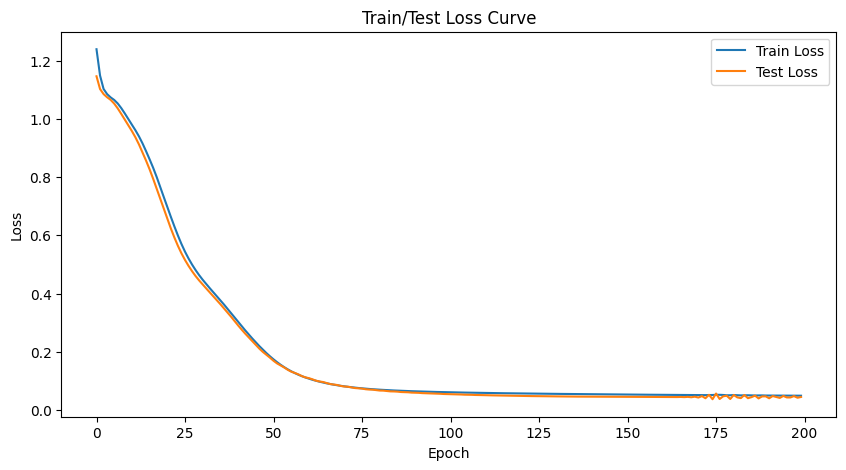

In [35]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

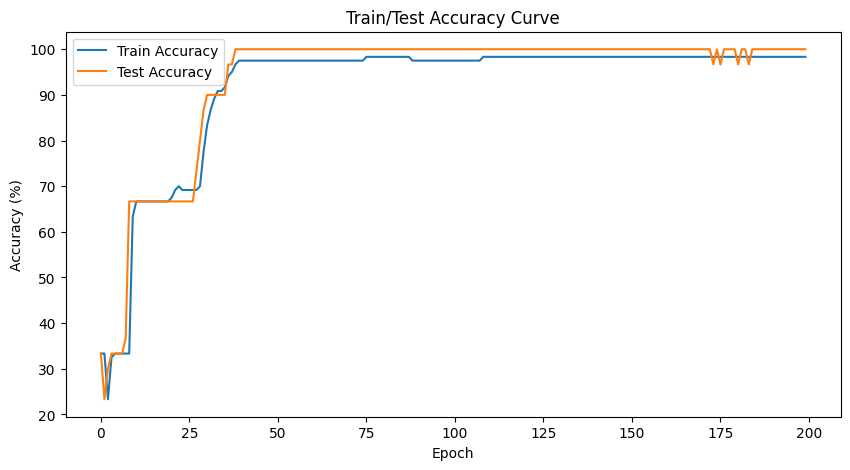

In [36]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

In [37]:
# let's say we got a new sample flower and try to figure out which class it belongs to

In [38]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]]) # 4 features in order

In [39]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [40]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

In [41]:
predicted_label = le.inverse_transform([predicted_class])[0]

In [42]:
print("Predicted Class Index:", predicted_class)
print("Predicted Species:", predicted_label)

Predicted Class Index: 0
Predicted Species: Iris-setosa


In [43]:
# torchmetrics

In [44]:
# we can use torhmetrics for eliminating writing calculate_accuracy functions etc. let's see

In [45]:
!pip install torchmetrics

In [46]:
from torchmetrics.classification import MulticlassAccuracy

In [47]:
accuracy = MulticlassAccuracy(num_classes=3)

In [48]:
# let's do training loop with torchmetrics

In [49]:
epochs = 200
model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)
for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### TEST ###
    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.0960 | Acc: 33.33% | Test Loss: 1.0349 | Test Acc: 33.33%
Epoch 20 | Loss: 0.5387 | Acc: 68.33% | Test Loss: 0.5142 | Test Acc: 66.67%
Epoch 40 | Loss: 0.1890 | Acc: 97.50% | Test Loss: 0.1804 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0718 | Acc: 97.50% | Test Loss: 0.0688 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0576 | Acc: 97.50% | Test Loss: 0.0460 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0534 | Acc: 98.33% | Test Loss: 0.0428 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0508 | Acc: 98.33% | Test Loss: 0.0422 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0489 | Acc: 98.33% | Test Loss: 0.0408 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0478 | Acc: 98.33% | Test Loss: 0.0408 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0459 | Acc: 98.33% | Test Loss: 0.0425 | Test Acc: 100.00%


In [50]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [51]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)

In [52]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

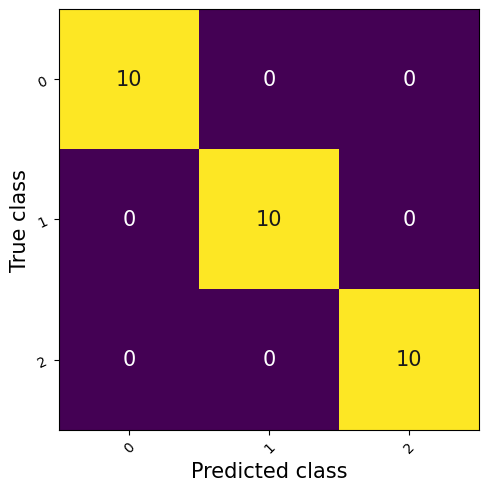

In [53]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [54]:
#model save - load - deploy

In [55]:
from pathlib import Path

In [56]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "iris_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH)

In [57]:
model2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.7051,  0.2996, -0.0254, -0.8125],
                      [ 0.2482, -0.4288,  0.4649,  0.3287],
                      [ 0.0751,  0.0679,  0.8375,  1.0117],
                      [-0.3016,  0.0529,  0.0109,  0.0431],
                      [ 0.0264,  0.6569, -0.3197, -0.3154],
                      [-0.1333, -0.0491,  0.7175,  0.6422],
                      [-0.2824,  0.3356, -0.4750, -0.1479],
                      [ 0.5878,  0.2216,  0.7435, -0.0102],
                      [-0.4853, -0.3648,  0.2379, -0.3460],
                      [-0.2480, -0.2186, -0.0598,  0.3973],
                      [-0.4043, -0.0741, -0.4998, -0.3243],
                      [-0.0755, -0.4262,  0.1875, -0.4754],
                      [-0.4697,  0.0089,  0.5869,  0.7819],
                      [-0.3437,  0.0159,  0.0241, -0.3549],
                      [ 0.3353, -0.4876,  0.2006,  0.9002],
                      [ 0.3412, -0.5940,  0.7888,  0.11

In [58]:
loaded_model = IrisClassifier()

In [59]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [60]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [61]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample_tensor = torch.tensor(new_sample, dtype = torch.float32)
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim = 1)
    predicted_class = torch.argmax(probs, dim=1).item()
le.inverse_transform([predicted_class])[0]

'Iris-setosa'